In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [3]:
from pathlib import Path
import pandas as pd

train_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)

In [14]:
train_df.loc[train_df["label"] == 1]

,filepath,label,mfcc_0_mean,mfcc_0_std,mfcc_0_min,mfcc_0_max,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,...,temporal_centroid,crest_factor,f0_mean,f0_std,voiced_fraction,hnr_db,band_low_ratio,band_mid_ratio,band_high_ratio,band_rotor_fundamental_ratio
700,Data_v2\Bootstrapped_Audios\train\audio_701.wav,1,-314.498749,47.044292,-441.727051,-261.855133,21.421665,13.845922,2.333780,58.661766,...,0.784700,4.867778,457.417836,68.838905,0.828571,0.614448,0.022900,0.496950,0.480150,0.020426
701,Data_v2\Bootstrapped_Audios\train\audio_702.wav,1,-361.146515,10.958445,-397.052917,-323.245697,13.017475,5.883268,-4.955222,29.732044,...,2.561156,4.597806,521.613924,6.380478,1.000000,11.277540,0.012192,0.618222,0.369586,0.008036
702,Data_v2\Bootstrapped_Audios\train\audio_703.wav,1,-337.862915,11.708470,-361.194489,-290.982666,13.341679,5.844857,-2.982174,39.986557,...,2.873168,5.611335,541.235773,13.812112,0.862903,7.412529,0.006480,0.610686,0.382792,0.005801
703,Data_v2\Bootstrapped_Audios\train\audio_704.wav,1,-442.935181,80.757927,-582.453491,-296.044098,23.099714,10.836650,2.862116,51.081398,...,1.869819,8.684997,558.536071,19.461447,0.818182,4.140244,0.001042,0.409833,0.589124,0.000870
704,Data_v2\Bootstrapped_Audios\train\audio_705.wav,1,-380.089569,94.839828,-593.087463,-157.229141,-16.905956,13.015641,-43.272675,20.442375,...,4.885932,15.231577,507.913474,324.256031,0.353933,-1.408834,0.004147,0.236590,0.759263,0.004043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395,Data_v2\Bootstrapped_Audios\train\audio_1396.wav,1,-508.435455,58.143902,-709.883423,-457.897827,47.188099,9.227885,27.895519,90.316284,...,1.903724,3.287218,100.695504,50.340208,0.813793,28.175611,0.938116,0.026073,0.035811,0.921617
1396,Data_v2\Bootstrapped_Audios\train\audio_1397.wav,1,-522.539612,7.960654,-572.906433,-451.571869,58.476067,7.611234,2.592124,84.365364,...,26.316585,5.807688,226.144219,46.960100,0.978330,20.961060,0.803193,0.180653,0.016154,0.802996
1397,Data_v2\Bootstrapped_Audios\train\audio_1398.wav,1,-528.535095,38.567387,-688.759460,-448.996704,127.140785,34.026814,8.078543,190.477539,...,28.635167,8.621834,160.531012,98.803967,0.272846,8.497269,0.522604,0.472546,0.004850,0.465626
1398,Data_v2\Bootstrapped_Audios\train\audio_1399.wav,1,-599.169983,116.512611,-757.458618,-312.494049,63.562176,24.699926,10.408276,101.884338,...,1.230867,14.105021,122.167543,74.564555,0.358696,7.030314,0.328383,0.422646,0.248972,0.327936


In [4]:
X_train = train_df.drop(columns=["filepath", "label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["filepath", "label"])
y_test = test_df["label"]

Batch Cross Validation

In [5]:
clf = RandomForestClassifier(n_estimators=200) #parameter tuning possible
 
cv = StratifiedKFold(n_splits=10, shuffle=True)
scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]
 
cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)
 
print("=== Cross-Validation Results (10-fold) ===")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:15s}: mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")
 

=== Cross-Validation Results (10-fold) ===
accuracy       : mean=0.9924  std=0.0047  folds=[0.986 0.99  0.992 0.988 0.986 0.998 0.996 0.998 0.998 0.994]
f1_macro       : mean=0.9924  std=0.0048  folds=[0.986 0.99  0.992 0.988 0.986 0.998 0.996 0.998 0.998 0.994]
precision_macro: mean=0.9927  std=0.0045  folds=[0.986 0.99  0.992 0.988 0.987 0.998 0.996 0.998 0.998 0.994]
recall_macro   : mean=0.9924  std=0.0047  folds=[0.986 0.99  0.992 0.988 0.986 0.998 0.996 0.998 0.998 0.994]


Test on Unseen Data

In [6]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

class_names = {'Airplanes': 0, 'Drones': 1, 'Explosion': 2, 'Gunshots': 3, 'Helicopter': 4, 'Land_Vehicles': 5, 'shortened_unlabeled': 6}
target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))


=== Final Held-Out Test ===
Test Accuracy: 0.6305
                     precision    recall  f1-score   support

          Airplanes       1.00      0.75      0.85        75
             Drones       0.94      0.20      0.33        75
          Explosion       0.61      0.79      0.69        75
           Gunshots       0.88      0.49      0.63        75
         Helicopter       0.61      0.80      0.69        75
      Land_Vehicles       0.52      0.53      0.53        75
shortened_unlabeled       0.46      0.85      0.60        75

           accuracy                           0.63       525
          macro avg       0.72      0.63      0.62       525
       weighted avg       0.72      0.63      0.62       525



Visualize


=== Final Held-Out Test ===
Test Accuracy: 0.6343
                     precision    recall  f1-score   support

          Airplanes       1.00      0.76      0.86        75
             Drones       1.00      0.21      0.35        75
          Explosion       0.61      0.79      0.69        75
           Gunshots       0.93      0.49      0.64        75
         Helicopter       0.60      0.73      0.66        75
      Land_Vehicles       0.52      0.57      0.55        75
shortened_unlabeled       0.46      0.88      0.61        75

           accuracy                           0.63       525
          macro avg       0.73      0.63      0.62       525
       weighted avg       0.73      0.63      0.62       525



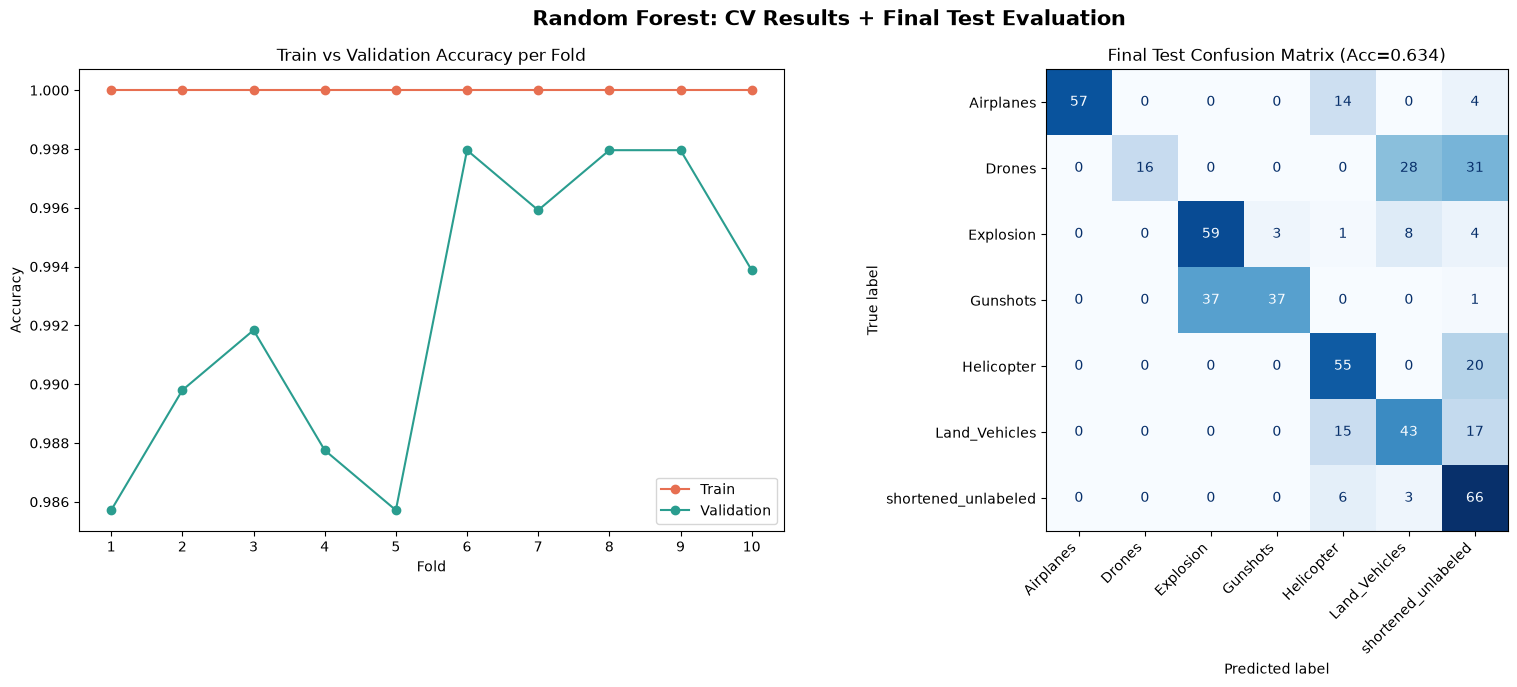

In [7]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Random Forest: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

# Train vs validation accuracy per fold (overfitting check)
ax = axes[0]
folds = np.arange(1, len(cv_results["test_accuracy"]) + 1)
ax.plot(folds, cv_results["train_accuracy"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_accuracy"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Validation Accuracy per Fold")
ax.legend()

# Confusion matrix on final held-out test set
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Final Test Confusion Matrix (Acc={test_acc:.3f})")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout

# Feature importances (from final fitted model)
feature_names = X_train.columns   # <-- feature columns only, matches clf.feature_importances_ length
importances = clf.feature_importances_
order = np.argsort(importances)


Feature Importance

In [8]:
def top_features_by_cumulative_importance(clf, feature_names, threshold=0.90):
    importances = clf.feature_importances_
    order = np.argsort(importances)[::-1]
    sorted_importances = importances[order]
    sorted_names = np.array(feature_names)[order]
    cumulative = np.cumsum(sorted_importances)
    n_features = np.searchsorted(cumulative, threshold) + 1
    return pd.DataFrame({
        "feature": sorted_names[:n_features],
        "importance": sorted_importances[:n_features],
        "cumulative": cumulative[:n_features]
    })

top_features_by_cumulative_importance(clf, X_train.columns, threshold=0.90)

,feature,importance,cumulative
0,temporal_centroid,0.038166,0.038166
1,mfcc_1_std,0.036572,0.074738
2,rms_std,0.024783,0.099521
3,decay_time,0.024181,0.123701
4,f0_mean,0.022242,0.145943
...,...,...,...
125,delta_8_min,0.002449,0.891682
126,mfcc_10_max,0.002431,0.894113
127,delta_9_min,0.002388,0.896502
128,delta2_4_max,0.002387,0.898888


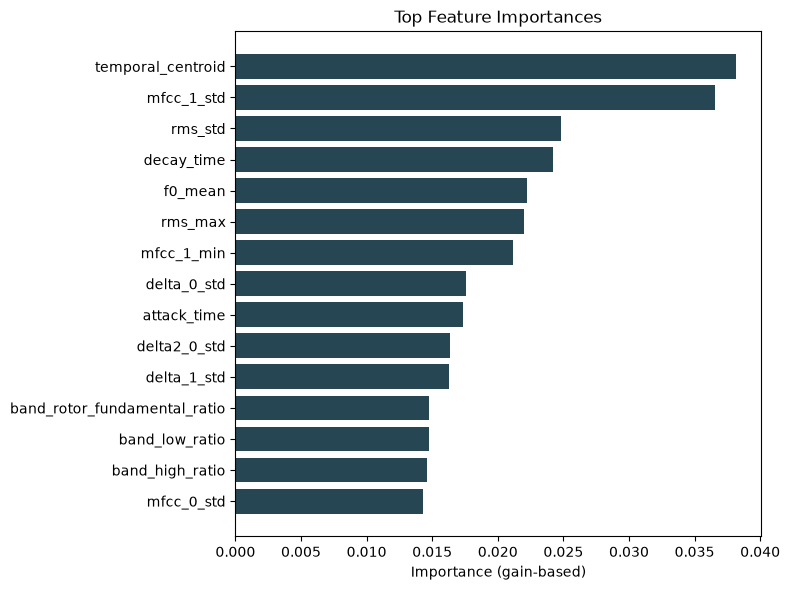

In [9]:
feature_names = X_train.columns
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top Feature Importances")
plt.tight_layout()
plt.show()

Parameter Tuning

In [10]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# -----------------------------
# 1. Define search space
# -----------------------------
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# -----------------------------
# 2. Run randomized search
#    scoring="f1_macro" weighs weak classes (like Gunshots) equally,
#    instead of letting accuracy hide behind the strong classes
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV f1_macro score:", random_search.best_score_)

clf_tuned = random_search.best_estimator_

# -----------------------------
# 3. Compare tuned vs default model on the SAME untouched test set
# -----------------------------
clf_default = RandomForestClassifier(n_estimators=200, random_state=42)
clf_default.fit(X_train, y_train)

for name, model in [("Default", clf_default), ("Tuned", clf_tuned)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} Model — Final Held-Out Test ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    print(f"Per-class recall ({name}):")
    for cname, r in zip(target_names, recall_per_class):
        print(f"  {cname:25s}: {r:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced_subsample'}
Best CV f1_macro score: 0.9916163914823839

=== Default Model — Final Held-Out Test ===
Test Accuracy: 0.6248
                     precision    recall  f1-score   support

          Airplanes       1.00      0.76      0.86        75
             Drones       1.00      0.17      0.30        75
          Explosion       0.59      0.79      0.67        75
           Gunshots       0.92      0.44      0.59        75
         Helicopter       0.60      0.77      0.67        75
      Land_Vehicles       0.53      0.56      0.55        75
shortened_unlabeled       0.46      0.88      0.61        75

           accuracy                           0.62       525
          macro avg       0.73      0.62      0.61       525
       weighted avg       0.73      0.62      0.61    

Adding additional features to improve performance

In [5]:
from Models import add_tonality_and_bpf_features
from pathlib import Path
import pandas as pd

df = pd.read_csv(r".\Data_v2\Bootstrapped_Audios\FeatureTable\test_df.csv")

df2 = add_tonality_and_bpf_features(df)

2026-07-22 09:16:57,852 - INFO - Adding tonality/BPF features [1/525]: Data_v2\Bootstrapped_Audios\test\audio_1.wav
2026-07-22 09:16:57,889 - INFO - Adding tonality/BPF features [2/525]: Data_v2\Bootstrapped_Audios\test\audio_2.wav
2026-07-22 09:16:57,922 - INFO - Adding tonality/BPF features [3/525]: Data_v2\Bootstrapped_Audios\test\audio_3.wav
2026-07-22 09:16:57,951 - INFO - Adding tonality/BPF features [4/525]: Data_v2\Bootstrapped_Audios\test\audio_4.wav
2026-07-22 09:16:57,981 - INFO - Adding tonality/BPF features [5/525]: Data_v2\Bootstrapped_Audios\test\audio_5.wav
2026-07-22 09:16:58,012 - INFO - Adding tonality/BPF features [6/525]: Data_v2\Bootstrapped_Audios\test\audio_6.wav
2026-07-22 09:16:58,039 - INFO - Adding tonality/BPF features [7/525]: Data_v2\Bootstrapped_Audios\test\audio_7.wav
2026-07-22 09:16:58,076 - INFO - Adding tonality/BPF features [8/525]: Data_v2\Bootstrapped_Audios\test\audio_8.wav
2026-07-22 09:16:58,110 - INFO - Adding tonality/BPF features [9/525]: D

In [6]:
df2.to_csv("test_df.csv", index=False)

Re-evaluating

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [10]:
from pathlib import Path
import pandas as pd

train_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)

X_train = train_df.drop(columns=["filepath", "label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["filepath", "label"])
y_test = test_df["label"]

Batch Cross Validation

In [11]:
clf = RandomForestClassifier(n_estimators=200) #parameter tuning possible
 
cv = StratifiedKFold(n_splits=10, shuffle=True)
scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]
 
cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)
 
print("=== Cross-Validation Results (10-fold) ===")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:15s}: mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")
 

=== Cross-Validation Results (10-fold) ===
accuracy       : mean=0.9941  std=0.0021  folds=[0.996 0.992 0.994 0.996 0.996 0.99  0.992 0.996 0.994 0.996]
f1_macro       : mean=0.9941  std=0.0021  folds=[0.996 0.992 0.994 0.996 0.996 0.99  0.992 0.996 0.994 0.996]
precision_macro: mean=0.9943  std=0.0020  folds=[0.996 0.992 0.994 0.996 0.996 0.99  0.992 0.996 0.994 0.996]
recall_macro   : mean=0.9941  std=0.0021  folds=[0.996 0.992 0.994 0.996 0.996 0.99  0.992 0.996 0.994 0.996]


Test on Unseen Data

In [12]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

class_names = {'Airplanes': 0, 'Drones': 1, 'Explosion': 2, 'Gunshots': 3, 'Helicopter': 4, 'Land_Vehicles': 5, 'shortened_unlabeled': 6}
target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))


=== Final Held-Out Test ===
Test Accuracy: 0.6324
                     precision    recall  f1-score   support

          Airplanes       1.00      0.77      0.87        75
             Drones       1.00      0.23      0.37        75
          Explosion       0.61      0.80      0.69        75
           Gunshots       0.89      0.45      0.60        75
         Helicopter       0.64      0.69      0.67        75
      Land_Vehicles       0.54      0.57      0.56        75
shortened_unlabeled       0.44      0.91      0.60        75

           accuracy                           0.63       525
          macro avg       0.73      0.63      0.62       525
       weighted avg       0.73      0.63      0.62       525



Visualize


=== Final Held-Out Test ===
Test Accuracy: 0.6076
                     precision    recall  f1-score   support

          Airplanes       1.00      0.76      0.86        75
             Drones       1.00      0.15      0.26        75
          Explosion       0.58      0.79      0.67        75
           Gunshots       0.86      0.43      0.57        75
         Helicopter       0.59      0.69      0.64        75
      Land_Vehicles       0.55      0.57      0.56        75
shortened_unlabeled       0.43      0.87      0.57        75

           accuracy                           0.61       525
          macro avg       0.72      0.61      0.59       525
       weighted avg       0.72      0.61      0.59       525



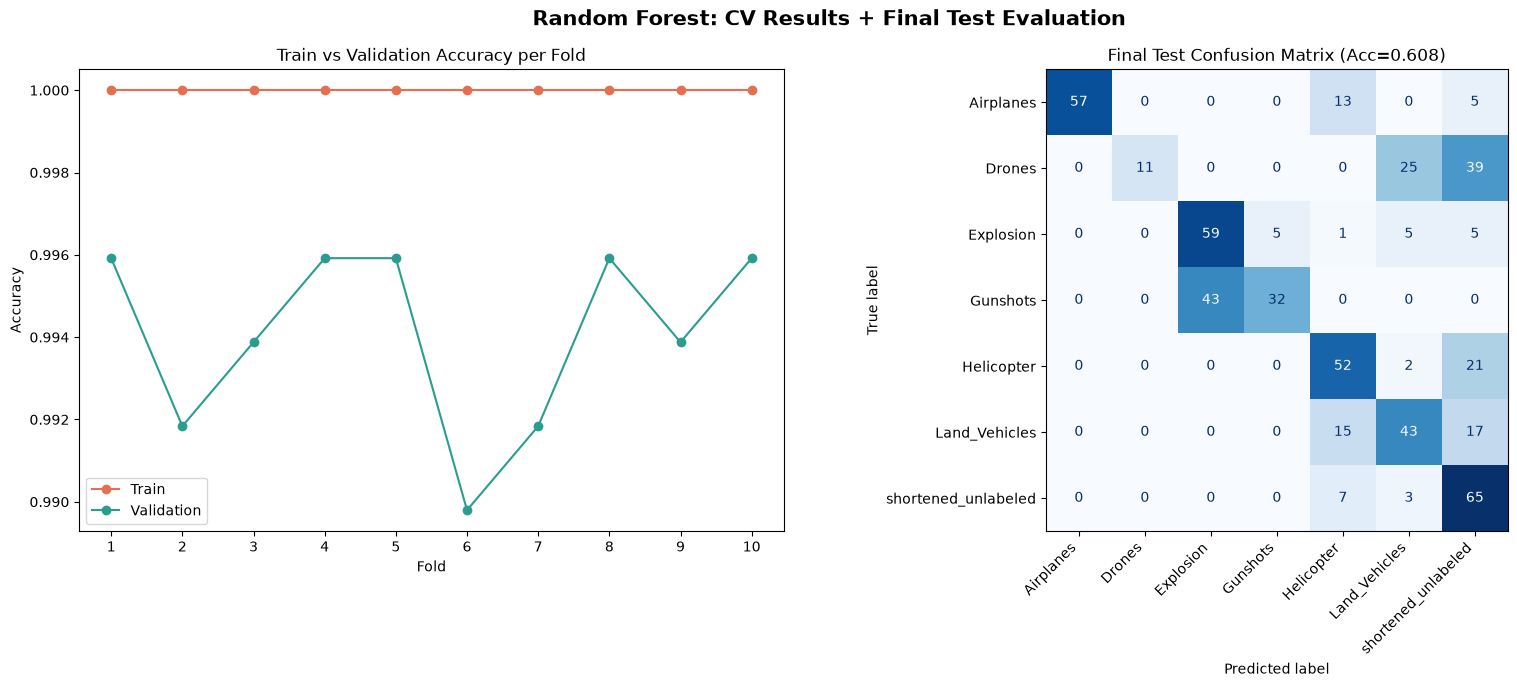

In [13]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Random Forest: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

# Train vs validation accuracy per fold (overfitting check)
ax = axes[0]
folds = np.arange(1, len(cv_results["test_accuracy"]) + 1)
ax.plot(folds, cv_results["train_accuracy"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_accuracy"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Validation Accuracy per Fold")
ax.legend()

# Confusion matrix on final held-out test set
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Final Test Confusion Matrix (Acc={test_acc:.3f})")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout

# Feature importances (from final fitted model)
feature_names = X_train.columns   # <-- feature columns only, matches clf.feature_importances_ length
importances = clf.feature_importances_
order = np.argsort(importances)

Feature Importance

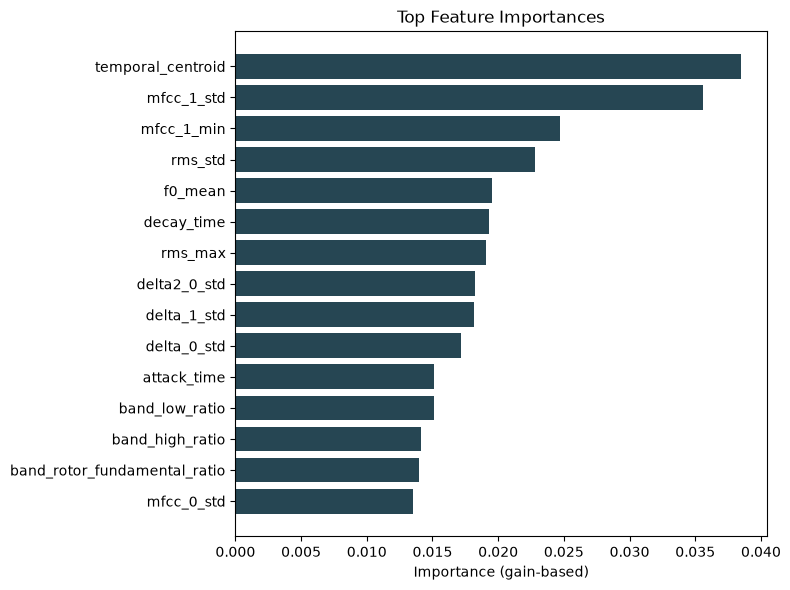

In [14]:
def top_features_by_cumulative_importance(clf, feature_names, threshold=0.90):
    importances = clf.feature_importances_
    order = np.argsort(importances)[::-1]
    sorted_importances = importances[order]
    sorted_names = np.array(feature_names)[order]
    cumulative = np.cumsum(sorted_importances)
    n_features = np.searchsorted(cumulative, threshold) + 1
    return pd.DataFrame({
        "feature": sorted_names[:n_features],
        "importance": sorted_importances[:n_features],
        "cumulative": cumulative[:n_features]
    })

top_features_by_cumulative_importance(clf, X_train.columns, threshold=0.90)

feature_names = X_train.columns
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top Feature Importances")
plt.tight_layout()
plt.show()

Param Tuning

In [15]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# -----------------------------
# 1. Define search space
# -----------------------------
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 20, 30, 35],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# -----------------------------
# 2. Run randomized search
#    scoring="f1_macro" weighs weak classes (like Gunshots) equally,
#    instead of letting accuracy hide behind the strong classes
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV f1_macro score:", random_search.best_score_)

clf_tuned = random_search.best_estimator_

# -----------------------------
# 3. Compare tuned vs default model on the SAME untouched test set
# -----------------------------
clf_default = RandomForestClassifier(n_estimators=200, random_state=42)
clf_default.fit(X_train, y_train)

for name, model in [("Default", clf_default), ("Tuned", clf_tuned)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} Model — Final Held-Out Test ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    print(f"Per-class recall ({name}):")
    for cname, r in zip(target_names, recall_per_class):
        print(f"  {cname:25s}: {r:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 35, 'class_weight': None}
Best CV f1_macro score: 0.9926503253387351

=== Default Model — Final Held-Out Test ===
Test Accuracy: 0.6305
                     precision    recall  f1-score   support

          Airplanes       1.00      0.76      0.86        75
             Drones       1.00      0.15      0.26        75
          Explosion       0.61      0.81      0.70        75
           Gunshots       0.95      0.47      0.62        75
         Helicopter       0.66      0.79      0.72        75
      Land_Vehicles       0.47      0.55      0.51        75
shortened_unlabeled       0.47      0.89      0.61        75

           accuracy                           0.63       525
          macro avg       0.74      0.63      0.61       525
       weighted avg       0.74      0.63      0.61       525

Per-clas

Re-evaluating w/o Land_Vehicles Class

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [11]:
from pathlib import Path
import pandas as pd

train_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)

#Dropping Land_Vehicle rows: encoding = 5
train_df = train_df.loc[train_df["label"] != 5]
test_df = test_df.loc[test_df["label"] != 5]

X_train = train_df.drop(columns=["filepath", "label"])
y_train = train_df["label"]


X_test = test_df.drop(columns=["filepath", "label"])
y_test = test_df["label"]

Batch Cross Validation

In [12]:
clf = RandomForestClassifier(n_estimators=200) #parameter tuning possible
 
cv = StratifiedKFold(n_splits=10, shuffle=True)
scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]
 
cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)
 
print("=== Cross-Validation Results (10-fold) ===")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:15s}: mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")
 

=== Cross-Validation Results (10-fold) ===
accuracy       : mean=0.9955  std=0.0043  folds=[0.986 0.995 1.    0.99  0.998 0.998 0.998 0.993 1.    0.998]
f1_macro       : mean=0.9955  std=0.0043  folds=[0.986 0.995 1.    0.99  0.998 0.998 0.998 0.993 1.    0.998]
precision_macro: mean=0.9956  std=0.0041  folds=[0.987 0.995 1.    0.991 0.998 0.998 0.998 0.993 1.    0.998]
recall_macro   : mean=0.9955  std=0.0043  folds=[0.986 0.995 1.    0.99  0.998 0.998 0.998 0.993 1.    0.998]


Test on Unseen Data

In [14]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

class_names = {'Airplanes': 0, 'Drones': 1, 'Explosion': 2, 'Gunshots': 3, 'Helicopter': 4, 'shortened_unlabeled': 6}
target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))


=== Final Held-Out Test ===
Test Accuracy: 0.6556
                     precision    recall  f1-score   support

          Airplanes       1.00      0.76      0.86        75
             Drones       0.93      0.17      0.29        75
          Explosion       0.64      0.87      0.74        75
           Gunshots       0.95      0.51      0.66        75
         Helicopter       0.73      0.72      0.72        75
shortened_unlabeled       0.41      0.91      0.57        75

           accuracy                           0.66       450
          macro avg       0.78      0.66      0.64       450
       weighted avg       0.78      0.66      0.64       450



Visualize


=== Final Held-Out Test ===
Test Accuracy: 0.6378
                     precision    recall  f1-score   support

          Airplanes       1.00      0.73      0.85        75
             Drones       1.00      0.20      0.33        75
          Explosion       0.60      0.84      0.70        75
           Gunshots       0.89      0.43      0.58        75
         Helicopter       0.71      0.73      0.72        75
shortened_unlabeled       0.42      0.89      0.57        75

           accuracy                           0.64       450
          macro avg       0.77      0.64      0.62       450
       weighted avg       0.77      0.64      0.62       450



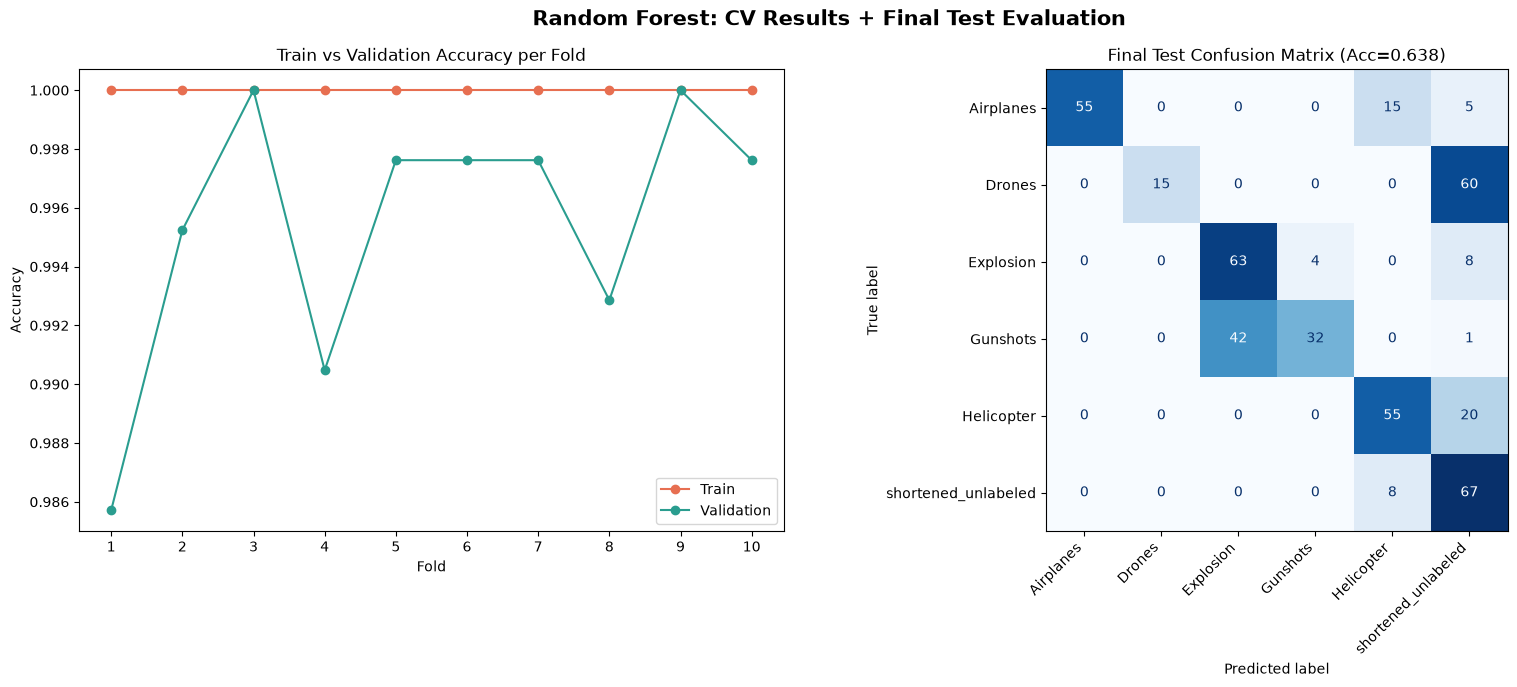

In [15]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Random Forest: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

# Train vs validation accuracy per fold (overfitting check)
ax = axes[0]
folds = np.arange(1, len(cv_results["test_accuracy"]) + 1)
ax.plot(folds, cv_results["train_accuracy"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_accuracy"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Validation Accuracy per Fold")
ax.legend()

# Confusion matrix on final held-out test set
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Final Test Confusion Matrix (Acc={test_acc:.3f})")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout

# Feature importances (from final fitted model)
feature_names = X_train.columns   # <-- feature columns only, matches clf.feature_importances_ length
importances = clf.feature_importances_
order = np.argsort(importances)

Feature Importance

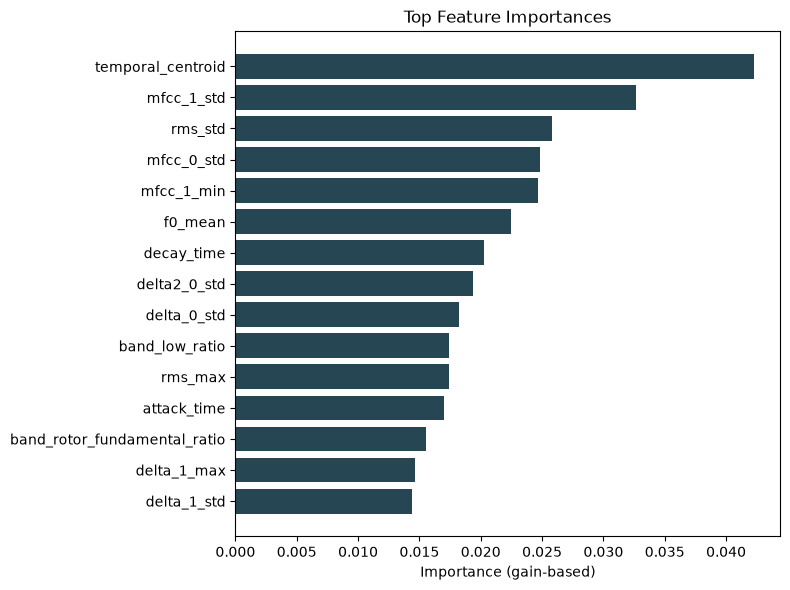

In [16]:
def top_features_by_cumulative_importance(clf, feature_names, threshold=0.90):
    importances = clf.feature_importances_
    order = np.argsort(importances)[::-1]
    sorted_importances = importances[order]
    sorted_names = np.array(feature_names)[order]
    cumulative = np.cumsum(sorted_importances)
    n_features = np.searchsorted(cumulative, threshold) + 1
    return pd.DataFrame({
        "feature": sorted_names[:n_features],
        "importance": sorted_importances[:n_features],
        "cumulative": cumulative[:n_features]
    })

top_features_by_cumulative_importance(clf, X_train.columns, threshold=0.90)

feature_names = X_train.columns
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top Feature Importances")
plt.tight_layout()
plt.show()

Param Tuning

In [17]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# -----------------------------
# 1. Define search space
# -----------------------------
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 20, 30, 35],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# -----------------------------
# 2. Run randomized search
#    scoring="f1_macro" weighs weak classes (like Gunshots) equally,
#    instead of letting accuracy hide behind the strong classes
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV f1_macro score:", random_search.best_score_)

clf_tuned = random_search.best_estimator_

# -----------------------------
# 3. Compare tuned vs default model on the SAME untouched test set
# -----------------------------
clf_default = RandomForestClassifier(n_estimators=200, random_state=42)
clf_default.fit(X_train, y_train)

for name, model in [("Default", clf_default), ("Tuned", clf_tuned)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} Model — Final Held-Out Test ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    print(f"Per-class recall ({name}):")
    for cname, r in zip(target_names, recall_per_class):
        print(f"  {cname:25s}: {r:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
Best CV f1_macro score: 0.9947578143699408

=== Default Model — Final Held-Out Test ===
Test Accuracy: 0.6622
                     precision    recall  f1-score   support

          Airplanes       1.00      0.75      0.85        75
             Drones       1.00      0.19      0.31        75
          Explosion       0.65      0.84      0.73        75
           Gunshots       0.93      0.52      0.67        75
         Helicopter       0.70      0.80      0.75        75
shortened_unlabeled       0.43      0.88      0.57        75

           accuracy                           0.66       450
          macro avg       0.78      0.66      0.65       450
       weighted avg       0.78      0.66      0.65       450

Per-class recall (Default):
  Airplanes                : 0.7467